In [1]:
!pwd

/home/labs/ahissarlab/bnassa/event-based-hyperacuity/notebooks


In [2]:
import os
import sys
sys.path.insert(1, os.getcwd()+'/..')

import numpy as np
import matplotlib.pyplot as plt

# import torch
# from torchvision import datasets, transforms
# from torch.utils.data import DataLoader
from eb_dataset import EB_DS, load_dataset

sensor_size = (60,60)

In [3]:
def get_events_dense_representations(evnts):
    n_pix = sensor_size[0]*sensor_size[1]

    pix_timestamp = [[] for _ in range(n_pix)]
    evnts_2d_hist = np.zeros(sensor_size)
    pix_column_timestamps = [[] for _ in range(sensor_size[0])]
    iei_per_pix_all = []
    first_ts_per_pix = np.zeros(sensor_size)

    evnt = {'x': 0, 'y': 0, 'timestamp': 0.0}
    for evnt_i in range(0,evnts.shape[0]):
        if len(evnts.shape)==2:
            evnt['x'] = int(evnts[evnt_i,1])
            evnt['y'] = int(evnts[evnt_i,2])
            evnt['timestamp'] = evnts[evnt_i,0]
        else:
            evnt['x'] = int(evnts[evnt_i]['x'])
            evnt['y'] = int(evnts[evnt_i]['y'])
            evnt['timestamp'] = evnts[evnt_i]['timestamp']
        
        evnts_2d_hist[int(evnt['x']), int(evnt['y'])] += 1
#         evnts_2d_hist[evnts[evnt_i,1], evnts[evnt_i,2]] += 1
        pix_indx = evnt['y'] + evnt['x']*sensor_size[1]

        if evnts_2d_hist[evnt['x'],evnt['y']] > 1:
            if len(pix_timestamp[pix_indx])!=0:
                iei = evnt['timestamp'] - pix_timestamp[pix_indx][-1]
                iei_per_pix_all.append(iei)
        else:
            first_ts_per_pix[evnt['x'],evnt['y']] = evnt['timestamp']

        pix_timestamp[pix_indx].append(evnt['timestamp'])
        pix_column_timestamps[evnt['x']].append(evnt['timestamp'])

    return pix_timestamp, evnts_2d_hist, iei_per_pix_all, first_ts_per_pix, pix_column_timestamps

# trial_indx = 1
# pix_timestamp, evnts_2d_hist, iei_per_pix_all, first_ts_per_pix, pix_column_timestamps= get_events_dense_representations(events_lst[trial_indx])

## Loading Vernier datasets & ploting a single example

In [14]:
num_points = 2000
# ds_vernier, labels, _ = load_dataset(base_path='/shareds/eb_datasets/20240623/Vernier/', n_samples=num_points, do_shuffle=False)
ds_vernier, labels, _ = load_dataset(base_path='../../datasets/eb_datasets/20250724/Vernier/', n_samples=num_points, do_shuffle=False)

loading ../../datasets/eb_datasets/20250724/Vernier/events.pkl...
../../datasets/eb_datasets/20250724/Vernier/labels.pkl


(1800.0, 2800.0)

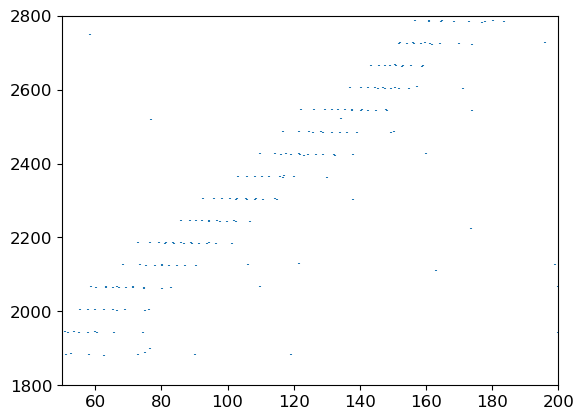

In [15]:
trial_ = 13
pix_timestamp_triali, _,_,_,_ = get_events_dense_representations(ds_vernier[trial_])

plt.figure()
_ = plt.eventplot(pix_timestamp_triali)
plt.xlim([50,200])
plt.ylim([1800,2800])

27


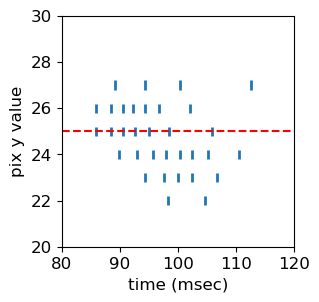

In [16]:
plt.rcParams.update({'font.size': 12})

x_coord = 37
trial_ = 13

first_pix_indx = x_coord*sensor_size[1]
#last_pix_indx = first_pix_indx + sensor_size[0]*2
last_pix_indx = first_pix_indx + sensor_size[0]

fig = plt.figure(figsize=(3,3))

pix_timestamp_triali, _,_,_,_ = get_events_dense_representations(ds_vernier[trial_])
plt.eventplot(pix_timestamp_triali[first_pix_indx:last_pix_indx], linelength=0.4, linewidth=2.0)
plt.axhline(y=25.0, color='r', linestyle='--')
# plt.xlim([40000,140000])
plt.ylabel('pix y value')
plt.xlabel('time (msec)')
# plt.title('Single-column raster plot, trial '+str(trial_)+', x_coord=' + str(x_coord))
# plt.figtext(0.5, 0.001, 'file: '+ path, ha="center", fontsize=10)
#plt.tight_layout()
#plt.savefig('Vernier_example_raster')

plt.xlim([80,120])
plt.ylim([20,30])
# plt.xlim([50,150])
# plt.ylim([20,30])
print(labels[trial_])

# import matplotlib as mpl
# mpl.rcParams['svg.fonttype'] = 'none' #for editable text in saved svg files
# plt.savefig('fig4panelC.svg', bbox_inches='tight')

## Loading Vernier calibration file & ploting a single example (60 pix column)

In [8]:
num_points = 2000
ds_vernier, labels, imu = load_dataset(base_path='../../datasets/eb_datasets//20240320/Vernier/train/', n_samples=num_points, do_shuffle=False)

loading ../../datasets/eb_datasets//20240320/Vernier/train/events.pkl...
../../datasets/eb_datasets//20240320/Vernier/train/labels.pkl


In [9]:
import pickle

#load recroded events and IMU signals
def load_imu_data(ds_path = '', use_train = True):
    
    ds_path_set = os.path.join(ds_path,'train') if use_train else os.path.join(ds_path_,'test')
    with open(os.path.join(ds_path_set, 'imu.pkl'),'rb') as f:
        imu_lst = pickle.load(f)

    return imu_lst

ds_imu = load_imu_data(ds_path='/shareds/eb_datasets/20240320/Vernier/', use_train=True)

FileNotFoundError: [Errno 2] No such file or directory: '/shareds/eb_datasets/20240320/Vernier/train/imu.pkl'

(100.0, 120.0)

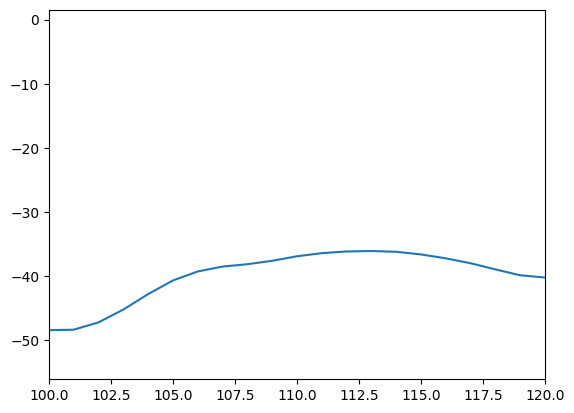

In [17]:
trial_ = 13

plt.figure()
plt.plot(ds_imu[trial_]['gyroscope1'])
plt.xlim([100, 120])

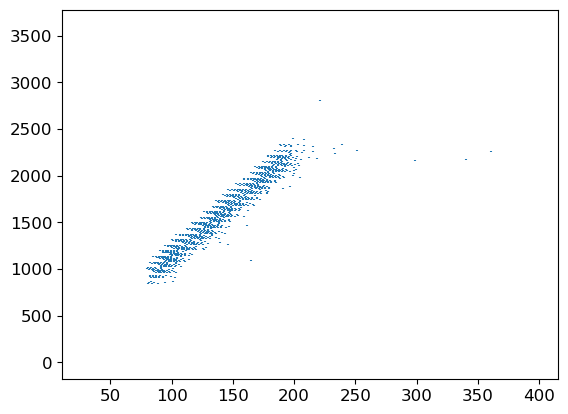

In [10]:
trial_ = 13
pix_timestamp_triali, _,_,_,_ = get_events_dense_representations(ds_vernier[trial_])

plt.figure()
_ = plt.eventplot(pix_timestamp_triali)
# plt.xlim([20,200])
# plt.ylim([900,2000])

27


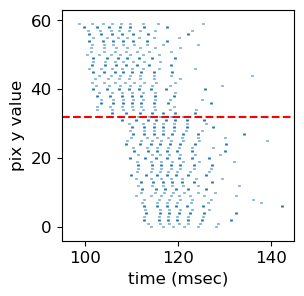

In [12]:
plt.rcParams.update({'font.size': 12})

x_coord = 21
trial_ = 13

first_pix_indx = x_coord*sensor_size[1]
#last_pix_indx = first_pix_indx + sensor_size[0]*2
last_pix_indx = first_pix_indx + sensor_size[0]

fig = plt.figure(figsize=(3,3))

pix_timestamp_triali, _,_,_,_ = get_events_dense_representations(ds_vernier[trial_])
plt.eventplot(pix_timestamp_triali[first_pix_indx:last_pix_indx], linelength=0.4, linewidth=2.0)
plt.axhline(y=32.0, color='r', linestyle='--')
# plt.xlim([40000,140000])
plt.ylabel('pix y value')
plt.xlabel('time (msec)')
# plt.title('Single-column raster plot, trial '+str(trial_)+', x_coord=' + str(x_coord))
# plt.figtext(0.5, 0.001, 'file: '+ path, ha="center", fontsize=10)
#plt.tight_layout()
#plt.savefig('Vernier_example_raster')

plt.xlim([95,145])
print(labels[trial_])

# import matplotlib as mpl
# mpl.rcParams['svg.fonttype'] = 'none' #for editable text in saved svg files
# plt.savefig('fig4panelB.svg', bbox_inches='tight')

27


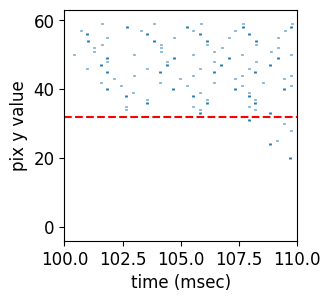

In [24]:
plt.rcParams.update({'font.size': 12})

x_coord = 21
trial_ = 13

first_pix_indx = x_coord*sensor_size[1]
#last_pix_indx = first_pix_indx + sensor_size[0]*2
last_pix_indx = first_pix_indx + sensor_size[0]

fig = plt.figure(figsize=(3,3))

pix_timestamp_triali, _,_,_,_ = get_events_dense_representations(ds_vernier[trial_])
plt.eventplot(pix_timestamp_triali[first_pix_indx:last_pix_indx], linelength=0.4, linewidth=2.0)
plt.axhline(y=32.0, color='r', linestyle='--')
# plt.xlim([40000,140000])
plt.ylabel('pix y value')
plt.xlabel('time (msec)')
# plt.title('Single-column raster plot, trial '+str(trial_)+', x_coord=' + str(x_coord))
# plt.figtext(0.5, 0.001, 'file: '+ path, ha="center", fontsize=10)
#plt.tight_layout()
#plt.savefig('Vernier_example_raster')

plt.xlim([100,110])
print(labels[trial_])